In [1]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

import scvi
import torch
import matplotlib.pyplot as plt
import spVIPESmulti

import seaborn as sns
from pathlib import Path

np.random.seed(0)
torch.manual_seed(0)
sc.settings.set_figure_params(dpi=80, frameon=False)

print(f"spVIPESmulti  : {spVIPESmulti.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"torch    : {torch.__version__} (CUDA available: {torch.cuda.is_available()})")
print(f"anndata  : {ad.__version__}")

spVIPESmulti  : 1.0.0
scvi-tools: 1.4.2
scanpy   : 1.12.1
torch    : 2.11.0+cu128 (CUDA available: True)
anndata  : 0.12.11


In [2]:
root = Path("/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/docs/notebooks/")
path_obs = root/"data/bcells_obs.csv"
path_rna = root/"data/bcells_rna.csv"

In [3]:
adata = ad.read_csv(path_rna, first_column_names=True)
obs = pd.read_csv(path_obs, index_col=0)
adata.obs = obs
adata.layers["counts"] = adata.X.copy()

In [4]:
adata = adata[adata.obs["antigen_specific"] != "Negative"]
adata.obs["antigen_class"] = (
    adata.obs["antigen_specific"].astype(str).str.strip().str.capitalize()
)
adata.obs["antigen_class"].value_counts()
adata

AnnData object with n_obs × n_vars = 9978 × 38605
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', '

### Dataset summary

In [5]:
for col in ["volunteer", "batch", "time", "cluster_label", "antigen_specific"]:
    print(f"── {col} ──")
    print(adata.obs[col].value_counts().to_string())
    print()

── volunteer ──
volunteer
817     2887
1160    2421
746     1760
825     1220
1333     852
888      838

── batch ──
batch
batch3    5140
batch2    3200
batch1    1638

── time ──
time
I2+14    2088
I3-1     1728
ZC-1     1667
I3+14    1377
I2-1     1348
I1+14    1266
I1-1      504

── cluster_label ──
cluster_label
Atypical           3155
Activated          2284
Classical          1653
Activated MZ        772
Naïve               687
Pre-Plasmablast     637
Transitional        434
Plasmablast         356

── antigen_specific ──
antigen_specific
CRXV     6898
NANP     2207
Njunc     873



In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3", batch_key="batch")
adata = adata[:, adata.var["highly_variable"]].copy()

In [7]:
from spVIPESmulti.utils import resolve_group_indices_list

# Split into per-antigen AnnData objects
antigen_specific = sorted(adata.obs["antigen_specific"].unique())
adatas_dict = {}
for ac in antigen_specific:
    sub = adata[adata.obs["antigen_specific"] == ac].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[ac] = sub
    print(f"  {ac}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

# Extract group indices once (used for training and latent extraction)
group_indices_list, _ = resolve_group_indices_list(adata_spv)

print(f"\nConcatenated AnnData: {adata_spv.shape}")
print(f"Groups             : {list(adata_spv.uns['groups_mapping'].values())}")
print(f"Group sizes        : {[len(g) for g in group_indices_list]}")

  CRXV: (6898, 3000)
  NANP: (2207, 3000)
  Njunc: (873, 3000)



Concatenated AnnData: (9978, 9000)
Groups             : ['CRXV', 'NANP', 'Njunc']
Group sizes        : [6898, 2207, 873]


In [8]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="antigen_specific",
    label_key="cluster_label",
    batch_key="batch"
)

INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          


INFO     spVIPESmulti: Setting up with groups_key: 'antigen_specific'                                              


INFO     spVIPESmulti: Labels: Using 'cluster_label' from adata.obs                                                


INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              


INFO     spVIPESmulti: Will use: Label-based PoE                                                                   


## Recommended training configuration

Changes from the baseline (`malaria_bcells.ipynb`) and their rationale:

| Change | Baseline | v1 | v2 | v3 | v4 (current) | Why |
|--------|----------|----|----|-----|--------------|-----|
| `group_loss_weights` | None (equal) | inverse group sizes | ← same | ← same | ← same | Corrects for ConcatDataLoader cycling: Njunc (~873 cells) is repeated ~8× per epoch relative to CRXV (~6898). Inverse-frequency weighting gives each group proportional gradient influence. |
| `lr` | 1e-3 | 5e-4 | ← same | ← same | ← same | Reduces instability in early epochs without sacrificing convergence speed. |
| `lr_scheduler` | plateau | plateau | plateau | **cosine** | ← same | ReduceLROnPlateau never fired in v2 (reconstruction was still declining at epoch 700 — LR stayed flat at 5e-4 throughout). CosineAnnealingLR decays on a fixed schedule regardless of plateau detection. |
| `lr_scheduler_metric` | `elbo_train` | `reconstruction_loss_validation` | ← same | removed | ← same | Not needed for cosine schedule. |
| `early_stopping_monitor` | `elbo_validation` | `reconstruction_loss_validation` | ← same | ← same | ← same | Stable signal throughout training regardless of warmup phase. |
| `check_val_every_n_epoch` | 10 | 5 | ← same | ← same | ← same | Finer resolution for early stopping. |
| `early_stopping_patience` | 20 | 15 | 20 | ← same | ← same | 20 × 5-epoch cadence = 100 epoch effective patience. |
| `n_hidden` | 128 | ← same | ← same | **256** | ← same | 128 compresses 3000 genes through a bottleneck; 256 is the `networks.py` default and gives the encoders sufficient width. |
| `disentangle_label_shared_weight` | 1.0 (preset) | 1.0 (preset) | 5.0 | 2.0 | **4.0** | Pilot sweep (150 ep, 4 variants): label_shared=4 gave best knn_purity (+6%) and leiden_ARI (+14%) vs baseline, with iLISI/kBET unchanged. |
| `batch_size` | 512 | ← same | ← same | **1024** | ← same | Lower gradient noise on L40S (ample VRAM headroom). |
| `max_epochs` | 300 | 400 | 700 | **400** | ← same | With cosine schedule + wider encoder, expect convergence by ~epoch 200–350. |

In [9]:
# Model hyperparameters
N_SHARED   = 20
N_PRIVATE  = 20
N_HIDDEN   = 256      # v3: 128→256 (wider encoder, matches networks.py default)
DROPOUT    = 0.1
MAX_EPOCHS = 400      # v3: cosine schedule + wider encoder should converge ~200-350 epochs
BATCH_SIZE = 1024     # v3: lower gradient noise on L40S
KL_WARMUP  = 75
LABEL_SHARED_W = 4  # v4: 2.0→4.0 (pilot sweep winner: +6% knn_purity, +14% leiden_ARI)
LABEL_PRIVATE_W = 0.05  # v4: 0.5→0.05 (N5-D fix: prevents GRL overreach on z_private)

# Derive group sizes from the prepared AnnData.
# Inverse-frequency weights  correct for ConcatDataLoader cycling imbalance:
# the smallest group (Njunc) is repeated ~8x per epoch relative to CRXV.
# The model normalizes these internally so they sum to 1.
GROUP_SIZES = [len(g) for g in group_indices_list]
GROUP_LOSS_WEIGHTS = [1/n**0.5 for n in GROUP_SIZES]
print("Group sizes:", dict(zip(adata_spv.uns["groups_mapping"].values(), GROUP_SIZES)))

model_spv = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="full",
    disentangle_label_shared_weight=LABEL_SHARED_W,
    disentangle_label_private_weight=LABEL_PRIVATE_W,
    # jeffreys integration
    use_jeffreys_integ=True,
    jeffreys_integ_weight=0.5,
    # Normalizing flow prior (optional):
    #use_nf_prior=True,
    #nf_type="MAF",               # "NSF" or "MAF"
    #nf_transforms=3,
    #nf_target="shared",          # "shared", "private", or "both"
    group_loss_weights=GROUP_LOSS_WEIGHTS,
)

Group sizes: {'CRXV': 6898, 'NANP': 2207, 'Njunc': 873}
INFO     spVIPESmulti: The model has been initialized                                                              


In [10]:
# Train with recommended hyperparameters (see rationale in the markdown cell above)
model_spv.train(
    group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=True,
    early_stopping_patience=20,                          # 20 × 5-epoch cadence = 100 epoch effective patience
    early_stopping_monitor="reconstruction_loss_validation",  # stable during KL warmup
    n_epochs_kl_warmup=KL_WARMUP,
    check_val_every_n_epoch=5,
    plan_kwargs={
        "lr": 5e-4,
        "lr_scheduler_type": "cosine",  # v3: replaces ReduceLROnPlateau which never fired in v2
        "lr_min": 1e-5,
    },
)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [11]:
# ── Training history summary ──────────────────────────────────────────────────
# Confirms whether early stopping fired and how each loss component evolved.
_h = model_spv.history
print(f"{'metric':45s}  {'first':>10}  {'final':>10}  {'drop':>10}  {'epochs':>7}")
print("-" * 90)
for _key in [
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "elbo_train",
    "kl_local_train",
]:
    if _key in _h and len(_h[_key]) > 0:
        _arr = np.asarray(
            [float(np.asarray(v).ravel()[0]) for v in _h[_key].to_numpy().ravel()],
            dtype=float,
        )
        _ok = np.isfinite(_arr).all()
        print(
            f"{_key:45s}  {_arr[0]:10.1f}  {_arr[-1]:10.1f}"
            f"  {_arr[0] - _arr[-1]:10.1f}  {len(_arr):7d}  {'OK' if _ok else 'NaN!'}"
        )
    else:
        print(f"{_key:45s}  (not recorded)")

metric                                              first       final        drop   epochs
------------------------------------------------------------------------------------------
reconstruction_loss_train                             1.2         1.0         0.2      400  OK
reconstruction_loss_validation                        3.2         2.8         0.4       80  OK
elbo_train                                            1.2         1.0         0.2      400  OK
kl_local_train                                        0.0         0.0        -0.0      400  OK


In [12]:
model_spv.save("results/spvipes_bcells_recommended_v4")

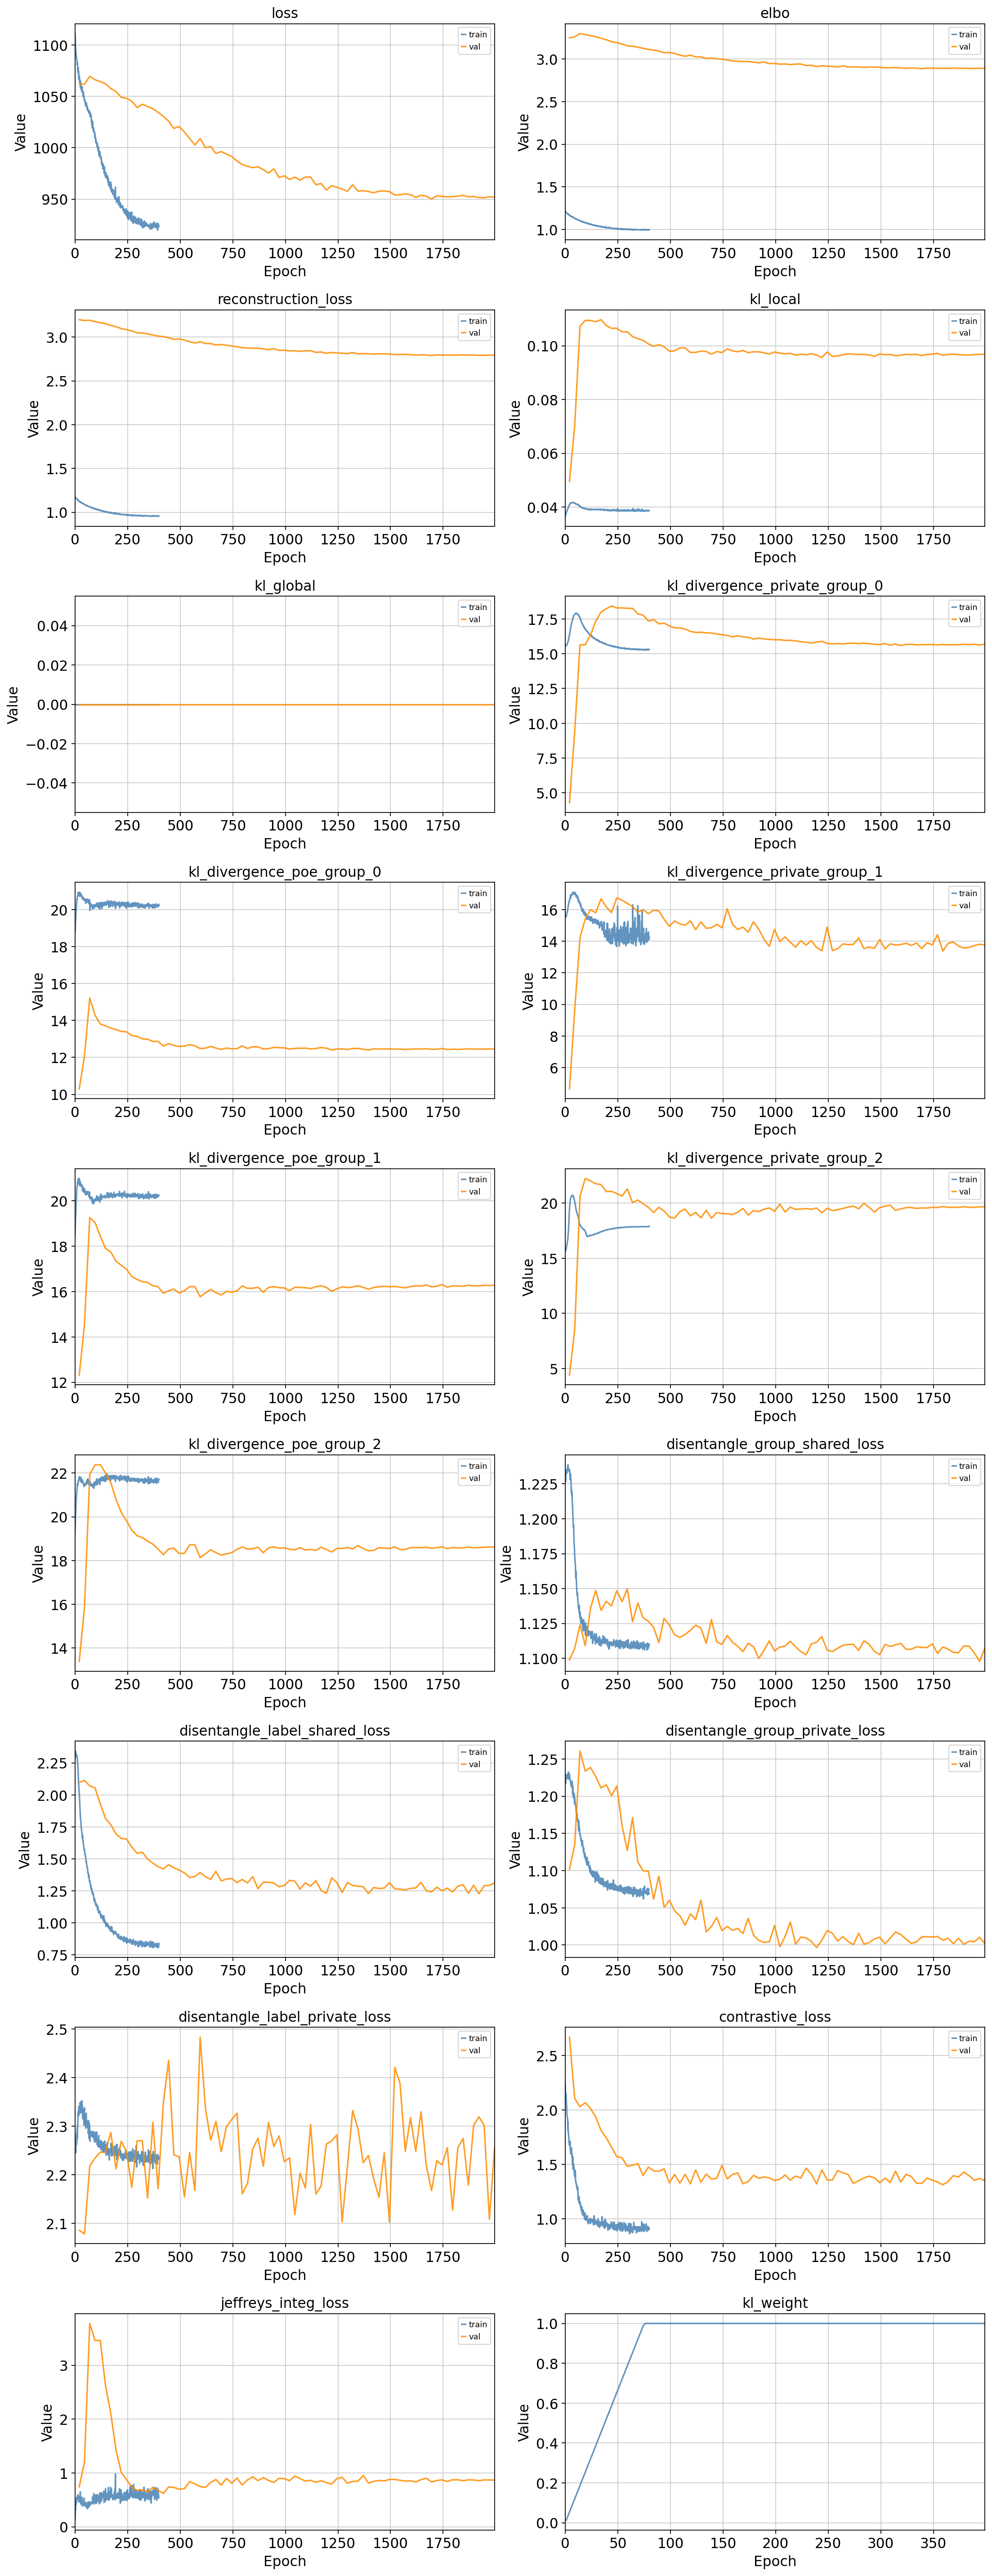

In [13]:
fig = spVIPESmulti.pl.training_curves(model_spv)

In [14]:
latents = model_spv.get_latent_representation(group_indices_list, batch_size=1024)
spVIPESmulti.utils.store_latents(adata_spv, latents, group_indices_list)

AnnData object with n_obs × n_vars = 9978 × 9000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 'M

In [15]:
# Shared latent UMAP (all groups integrated):
spVIPESmulti.utils.compute_shared_umap(adata_spv, n_neighbors=20, min_dist=1)

AnnData object with n_obs × n_vars = 9978 × 9000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 'M

### Quantitative latent-space evaluation

Group mixing (higher = better): **iLISI**, **kBET**  
Label structure (higher = better): **k-NN purity**, **Leiden ARI**  
Label separation (lower = better): **cLISI**  
Private-latent group separation (higher = better): **silhouette**

In [16]:
# ── Integration report ────────────────────────────────────────────────────────
from spVIPESmulti.metrics import integration_report

z_shared = adata_spv.obsm["X_spVIPESmulti_shared"]
_groups_map = adata_spv.uns["groups_mapping"]

# Per-group private latents keyed by group name
z_private_dict = {
    str(_groups_map.get(gi, gi)): latents["private_reordered"][gi]
    for gi in range(len(group_indices_list))
}

_report = integration_report(
    z_shared,
    adata_spv.obs["antigen_specific"].values,
    adata_spv.obs["cluster_label"].values,
    z_private_dict=z_private_dict,
    k=20,
)
print(_report.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

           latent  ilisi  clisi  kbet  knn_purity  leiden_ari  silhouette
         z_shared  1.885  1.729 0.883       0.684       0.387         NaN
 z_private (CRXV)    NaN    NaN   NaN         NaN         NaN       0.047
 z_private (NANP)    NaN    NaN   NaN         NaN         NaN       0.047
z_private (Njunc)    NaN    NaN   NaN         NaN         NaN       0.047


In [17]:
# ── Failure-mode audit ────────────────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors as _NNS
from sklearn.metrics import roc_auc_score as _auc

_K = 20
_labels = adata_spv.obs["cluster_label"].values
_nn = _NNS(n_neighbors=_K + 1).fit(z_shared)
_, _idx = _nn.kneighbors(z_shared)
_idx = _idx[:, 1:]

# Per-cell-type k-NN purity
_purity = np.array([((_labels[_idx[i]] == _labels[i]).mean()) for i in range(len(_labels))])
_purity_df = (
    pd.DataFrame({"cluster_label": _labels, "knn_purity": _purity})
    .groupby("cluster_label")["knn_purity"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)
print("Per-cell-type k-NN purity (k=20) in z_shared — lower = harder to separate:")
print(_purity_df.to_string(float_format=lambda x: f"{x:.3f}"))

# One-vs-rest AUROC per shared dimension
_Z = z_shared
_cell_types = sorted(np.unique(_labels))
_auroc = np.full((len(_cell_types), _Z.shape[1]), np.nan)
for _ci, _ct in enumerate(_cell_types):
    _y = (_labels == _ct).astype(int)
    if _y.sum() < 5 or (1 - _y).sum() < 5:
        continue
    for _di in range(_Z.shape[1]):
        try:
            _auroc[_ci, _di] = _auc(_y, _Z[:, _di])
        except Exception:
            pass

_auroc_df = pd.DataFrame(
    _auroc, index=_cell_types,
    columns=[f"shared_{i}" for i in range(_Z.shape[1])],
)
_best_dim_per_type = _auroc_df.max(axis=1).sort_values()
print("\nBest shared-dim one-vs-rest AUROC per cell type (closer to 1.0 = more separable):")
print(_best_dim_per_type.to_string(float_format=lambda x: f"{x:.3f}"))

# Island / outlier check: antigen × batch breakdown per cell type
print("\nCell count by cluster_label × antigen_specific (check for island-causing confounds):")
print(
    pd.crosstab(
        adata_spv.obs["cluster_label"],
        adata_spv.obs["antigen_specific"],
    ).to_string()
)

Per-cell-type k-NN purity (k=20) in z_shared — lower = harder to separate:
                 mean   std  count
cluster_label                     
Activated MZ    0.383 0.268    772
Pre-Plasmablast 0.570 0.293    637
Activated       0.582 0.233   2284
Transitional    0.585 0.337    434
Plasmablast     0.642 0.340    356
Naïve           0.700 0.292    687
Atypical        0.797 0.203   3155
Classical       0.819 0.229   1653



Best shared-dim one-vs-rest AUROC per cell type (closer to 1.0 = more separable):
Plasmablast       0.694
Activated MZ      0.694
Activated         0.744
Pre-Plasmablast   0.804
Atypical          0.889
Classical         0.898
Transitional      0.918
Naïve             0.931

Cell count by cluster_label × antigen_specific (check for island-causing confounds):
antigen_specific  CRXV  NANP  Njunc
cluster_label                      
Activated         1609   470    205
Activated MZ       468   254     50
Atypical          2242   685    228
Classical         1142   295    216
Naïve              416   216     55
Plasmablast        263    66     27
Pre-Plasmablast    471   114     52
Transitional       287   107     40


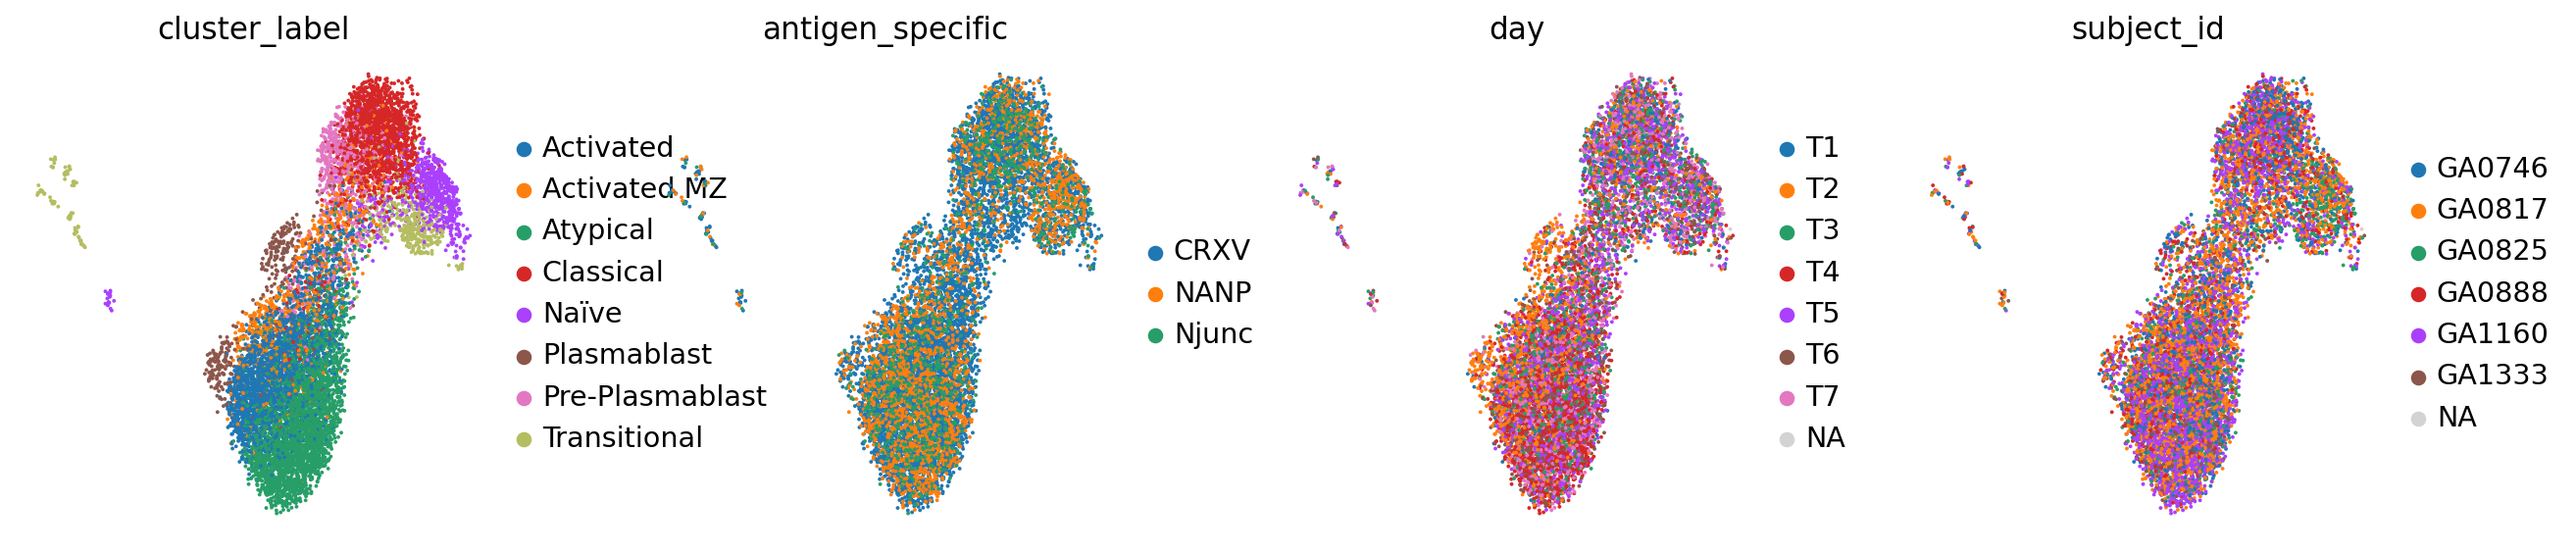

In [18]:
spVIPESmulti.pl.umap_shared(adata_spv, color=["cluster_label", "antigen_specific", "day", "subject_id"])

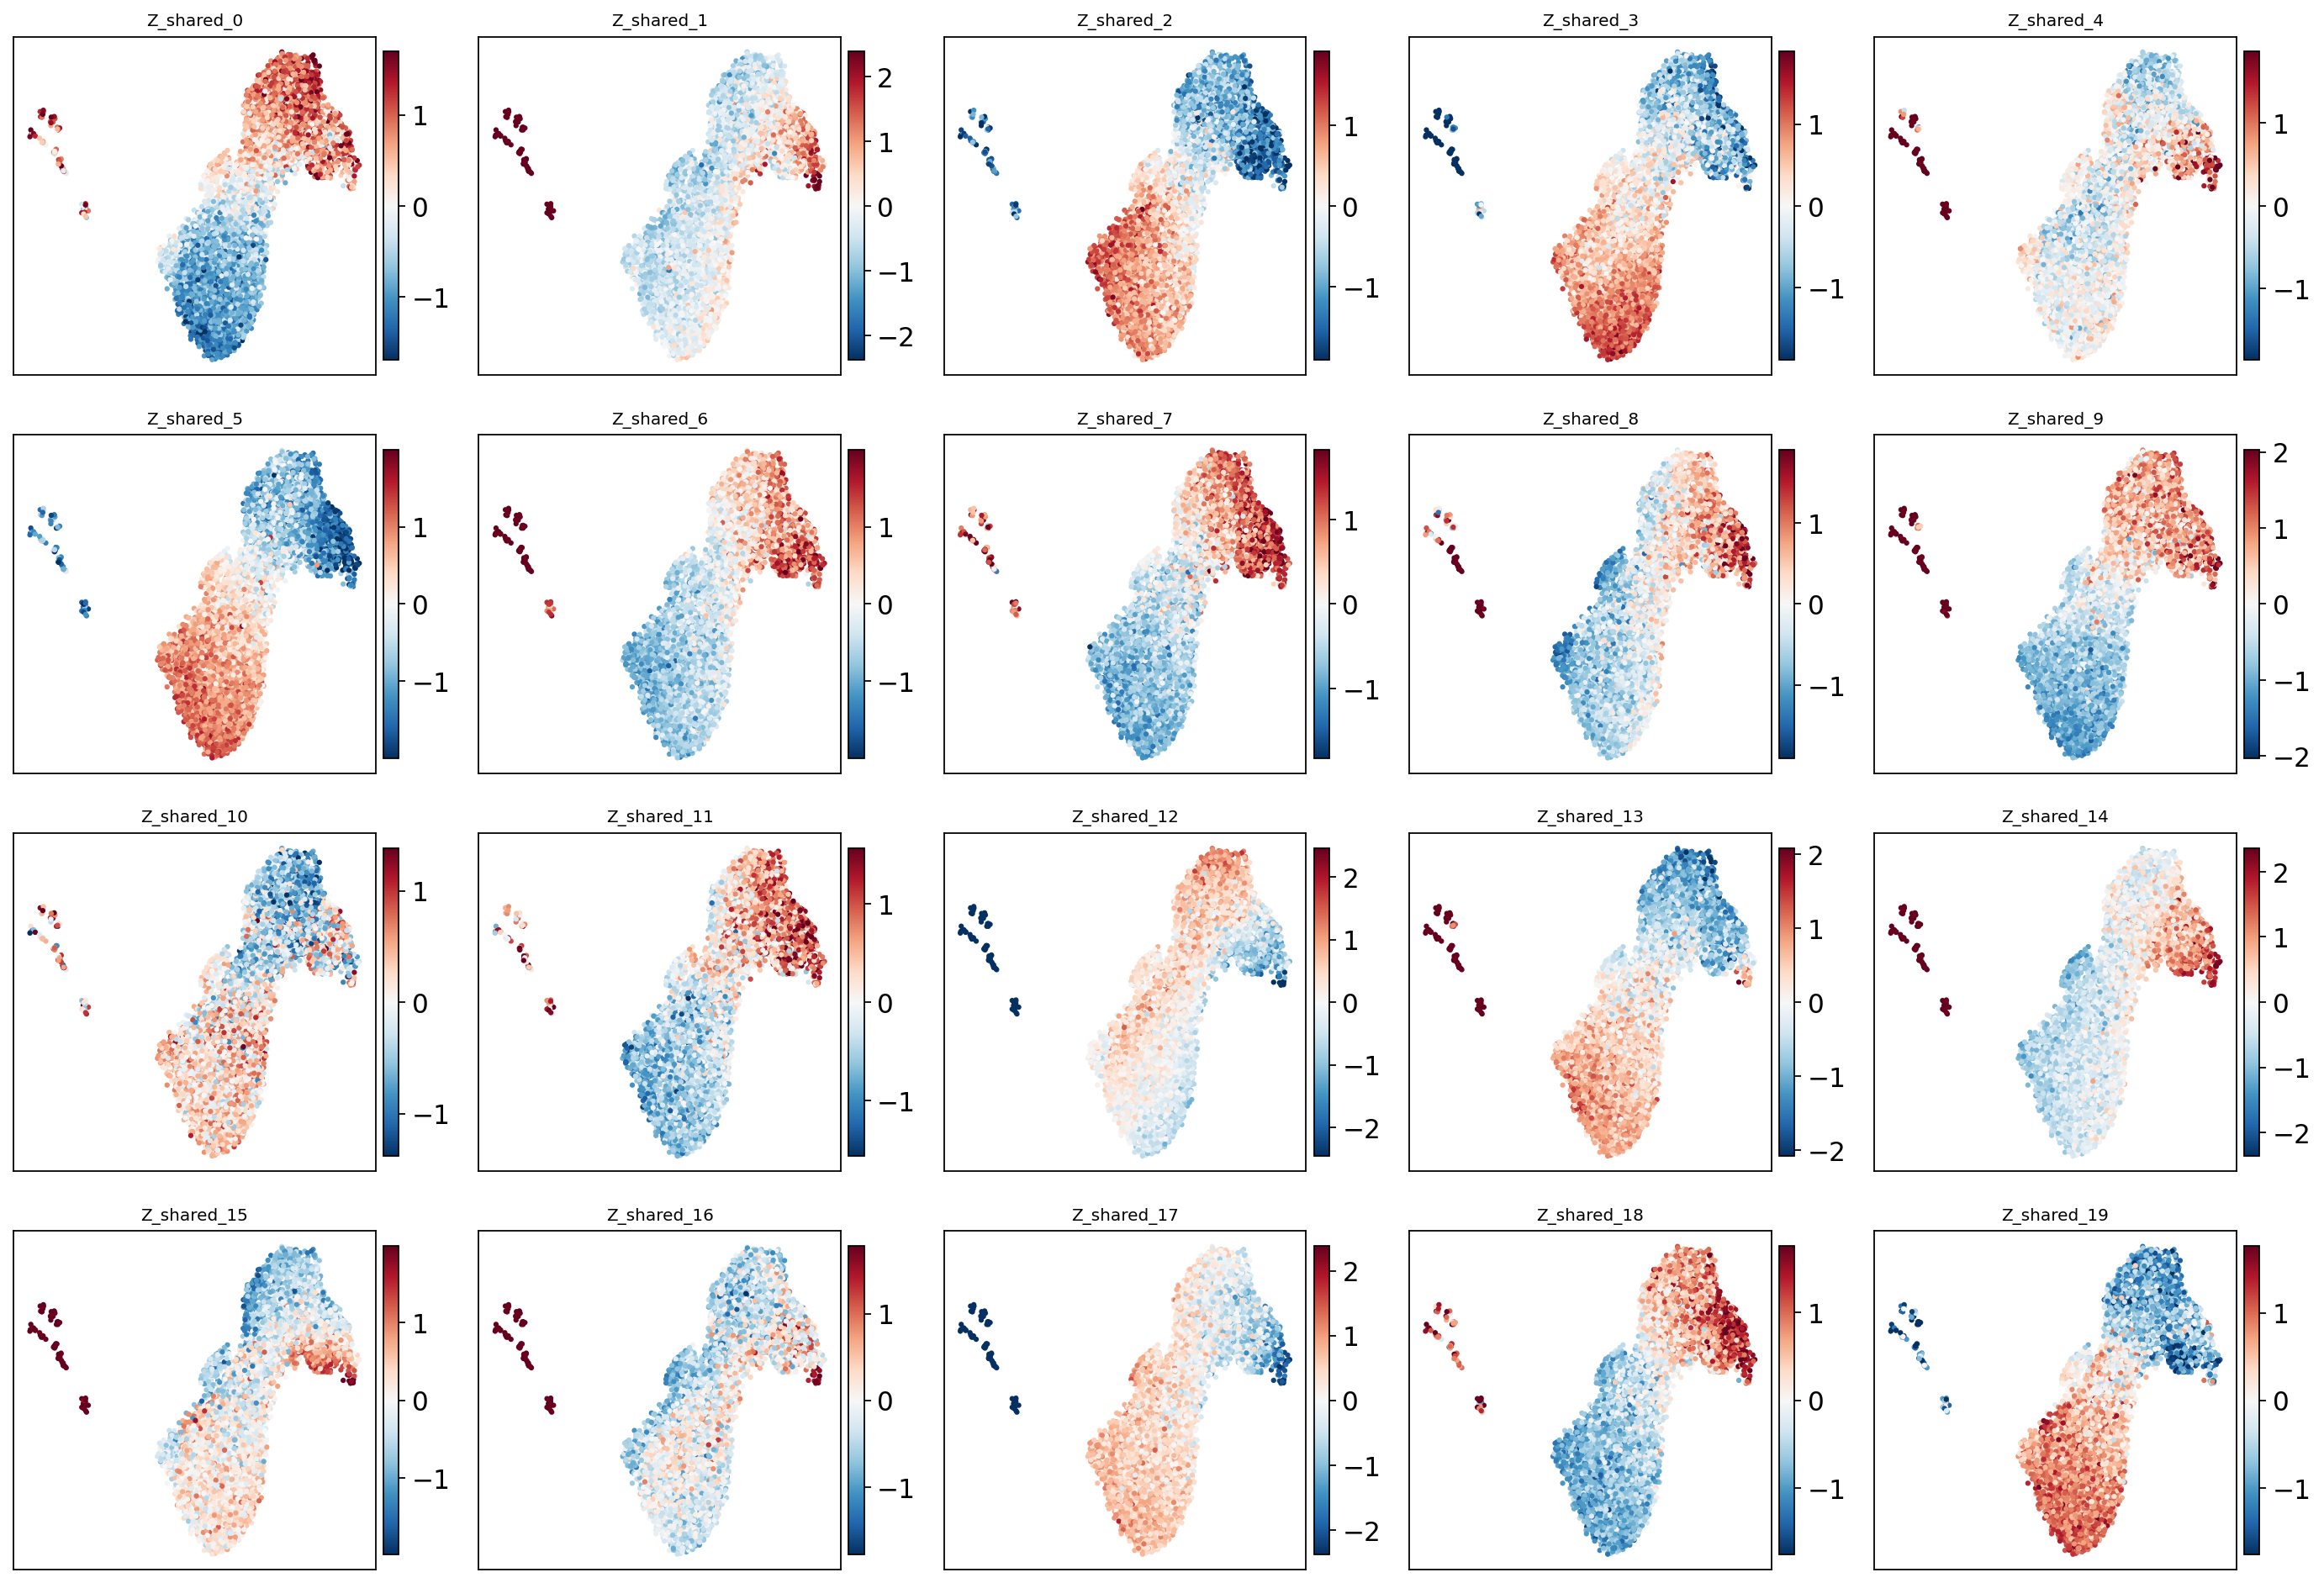

In [19]:
fig = spVIPESmulti.pl.plot_latent_dims_in_umap(adata_spv, "X_spVIPESmulti_shared")

In [20]:
import datetime
print(f"Run date      : {datetime.date.today()}")
print(f"spVIPESmulti  : {spVIPESmulti.__version__}")
print(f"scvi-tools    : {scvi.__version__}")
print(f"scanpy        : {sc.__version__}")
print(f"torch         : {torch.__version__}")

Run date      : 2026-05-08
spVIPESmulti  : 1.0.0
scvi-tools    : 1.4.2
scanpy        : 1.12.1
torch         : 2.11.0+cu128
